**QUADCOPTOR CASCADE PID CONTROL**

This notebook implements a Cascade PID Controller for quadcopter trajectory tracking. Using a nonlinear 6-DOF rigid body model, it tracks a figure-8 reference trajectory by solving three nested PID control loops at different rates, while simulating the closed-loop quadcopter dynamics using c4dynamics.

**1) SYSTEM MODEL**

We consider a nonlinear rigid body model of a quadcopter with 12 state variables:

X= [x, y, z, x˙, y˙​, z˙, ϕ, θ, ψ, p, q, r]T


where:

x, y, z : inertial position [m]

x˙,y˙,z˙ : inertial velocity [m/s]

ϕ,θ,ψ : roll, pitch, yaw Euler angles [rad]

p,q,r : body angular rates [rad/s]




**CONTROL OBJECTIVE**

The primary goal is to track a figure-8 trajectory at constant altitude. Four independent control inputs are used:

U=[F,τϕ​,τθ​,τψ​]T

where F is total thrust and τϕ​,τθ​,τψ​ are roll, pitch, and yaw torques. In this implementation we assume ideal state measurements and focus on the cascade PID control architecture. In practical applications, sensors such as IMU, GPS, and barometer combined with a Kalman filter would be used to estimate the full state vector.

**SETUP AND PARAMETERS**

1) Import Required Packages

In [37]:
import sys
if "google.colab" in sys.modules:
    !pip install c4dynamics -q

import c4dynamics as c4d
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

2) Physical Parameters

In [38]:
m   = 1.0       # mass [kg]
g   = 9.81      # gravity [m/s²]
Ixx = 0.0196    # moment of inertia — roll  [kg.m²]
Iyy = 0.0196    # moment of inertia — pitch [kg.m²]
Izz = 0.0264    # moment of inertia — yaw   [kg.m²]
l   = 0.225     # arm length [m]
kT  = 1.0       # thrust coefficient (normalized)
kQ  = 0.01      # torque coefficient (normalized)

3) Define Simulation Step and Duration

In [39]:
dt    = 0.005    # master timestep — inner loop rate (200 Hz)
t_end = 40.0     # simulation duration [s]

4) Define Trajectory Parameters

In [40]:
A     = 1.5    # figure-8 amplitude in x [m]
B     = 1.0    # figure-8 amplitude in y [m]
omega = 0.3    # figure-8 angular frequency [rad/s]
z_ref = 1.5    # constant reference altitude [m]

5) Define Control Allocation Matrix

In [41]:
# Maps [F, tau_phi, tau_theta, tau_psi] → [Ω1², Ω2², Ω3², Ω4²]
# Motor layout — plus (+) configuration:
#   Motor 1: front (+x) CW    Motor 2: left  (+y) CCW
#   Motor 3: rear  (-x) CW    Motor 4: right (-y) CCW

Gamma = np.array([
    [ kT,      kT,     kT,     kT   ],
    [ 0,      -kT*l,   0,      kT*l ],
    [ kT*l,    0,     -kT*l,   0    ],
    [ kQ,     -kQ,     kQ,    -kQ   ]
])

Gamma_inv = np.linalg.inv(Gamma)

**INITIALIZE QUADCOPTER STATE**

Use c4dynamics.rigidbody to define and store the quadcopter state during simulation. The rigidbody class provides all 12 state variables pre-defined, along with built-in mass and I properties

In [42]:
quad      = c4d.rigidbody(z=1.5)   # start at reference altitude
quad.mass = m                       # mass [kg]
quad.I    = [Ixx, Iyy, Izz]        # moments of inertia [kg.m²]

Attach control inputs as quadcopter parameters. These are stored each timestep alongside the state using storeparams

In [43]:
quad.F         = m * g   # total thrust — initialized at hover [N]
quad.tau_phi   = 0.0     # roll  torque [N.m]
quad.tau_theta = 0.0     # pitch torque [N.m]
quad.tau_psi   = 0.0     # yaw   torque [N.m]

**QUADCOPTOR DYNAMICS FUNCTION**

The dynamics function encodes the full nonlinear Newton-Euler equations of motion. It is called by solve_ivp at every integration step and returns the state derivative vector X˙

In [44]:
def quad_dynamics(t, X, F, tau_phi, tau_theta, tau_psi):
    """
    Quadcopter nonlinear equations of motion.

    Inputs
    ------
    X   : current state vector [12x1]
          [x, y, z, vx, vy, vz, phi, theta, psi, p, q, r]
    F   : total thrust [N]
    tau_phi, tau_theta, tau_psi : body torques [N.m]

    Returns
    -------
    X_dot : state derivative vector [12x1]
    """

    x, y, z, vx, vy, vz, phi, theta, psi, p, q, r = X

    # Trigonometric shorthands
    cphi   = np.cos(phi);    sphi   = np.sin(phi)
    ctheta = np.cos(theta);  stheta = np.sin(theta)
    cpsi   = np.cos(psi);    spsi   = np.sin(psi)
    ttheta = np.tan(theta)

    # Translational kinematics — position rates equal velocities
    x_dot = vx
    y_dot = vy
    z_dot = vz

    # Translational dynamics — thrust projected into inertial
    # frame via the 3-2-1 rotation matrix
    vx_dot = (F/m) * (cpsi*stheta*cphi + spsi*sphi)
    vy_dot = (F/m) * (spsi*stheta*cphi - cpsi*sphi)
    vz_dot = (F/m) * (ctheta*cphi) - g

    # Rotational kinematics — body rates to Euler angle rates
    phi_dot   = p + (q*sphi + r*cphi) * ttheta
    theta_dot = q*cphi - r*sphi
    psi_dot   = (q*sphi + r*cphi) / (ctheta + 1e-6)

    # Rotational dynamics — Euler's equations of motion
    p_dot = ((Iyy - Izz)/Ixx) * q*r + tau_phi/Ixx
    q_dot = ((Izz - Ixx)/Iyy) * p*r + tau_theta/Iyy
    r_dot = ((Ixx - Iyy)/Izz) * p*q + tau_psi/Izz

    return [x_dot, y_dot, z_dot,
            vx_dot, vy_dot, vz_dot,
            phi_dot, theta_dot, psi_dot,
            p_dot, q_dot, r_dot]

**2) CASCADE PID CONTROLLER**

The quadcopter is controlled using a Cascade PID Controller. A cascade PID is composed of three core elements:

**Outer Loop** — Position Controller (50 Hz): Takes the position error between the reference trajectory and current position. Outputs desired attitude angles (ϕdes,θdes) and a thrust correction δF. This is the slowest loop — it sets the high-level flight objectives.

**Middle Loop** — Attitude Controller (100 Hz): Takes the attitude error between the desired angles from the outer loop and the current Euler angles. Outputs desired body angular rates (pdes,qdes,rdes).This loop must be faster than the position loop to ensure the quadcopter achieves the commanded attitude before a new attitude command arrives.

**Inner Loop** — Rate Controller (200 Hz): Takes the rate error between the desired rates from the middle loop and the current body rates. Outputs body torques (τϕ,τθ,τψ).This is the fastest loop — it directly commands the actuators and must be stable before the outer loops can function correctly.

A cascade architecture is suitable for quadcopter control because each loop operates at a bandwidth that is 3-5× higher than the loop outside it, ensuring stability and preventing loop interactions. Unlike a single-loop PID, the cascade structure separates attitude stabilization from position tracking, allowing independent tuning of each layer.

**2.1) PID Control Law**

Each of the nine PID controllers implements the following control law:

u = Kp⋅e + Ki∫edt - Kd⋅m˙

where e is the tracking error, ∫edt is the accumulated integral, and m˙ is the derivative of the
measurement rather than the error. Taking the derivative on measurement rather than error prevents the derivative kick — the large impulsive output that occurs when the reference changes suddenly.

**Anti-Windup:** The integrator is clamped to a symmetric limit ±Ilim to prevent
integrator windup — a condition where the integrator accumulates a very large value during saturation, causing a slow and oscillatory recovery when the system returns to normal operation.

**Derivative Filter:** The raw derivative is passed through a first-order low-pass filter with coefficient N:

α = N.dt/ 1+N.dt

m˙filtered = (1-α)m˙prev + αm˙raw

prevents high-frequency noise amplification in the derivative channel.

In [45]:
class PID:
    """
    PID controller with:
      - Derivative filter     (Prevents high-frequency noise amplification)
      - Anti-windup           (Integrator clamping)
      - Derivative on measurement (Prevents derivative kick)
    """

    def __init__(self, Kp, Ki, Kd, dt,
                 N              = 20,
                 output_limit   = None,
                 integral_limit = None):
        """
        Parameters
        ----------
        Kp, Ki, Kd     : PID gains
        dt             : timestep for this loop [s]
        N              : derivative filter coefficient
                         N=50 → inner loop (rate)
                         N=20 → middle loop (attitude)
                         N=10 → outer loop (position)
        output_limit   : symmetric clamp on controller output
        integral_limit : symmetric clamp on integrator (anti-windup)
        """
        self.Kp = Kp
        self.Ki = Ki
        self.Kd = Kd
        self.dt = dt
        self.N  = N

        self.output_limit   = output_limit
        self.integral_limit = integral_limit

        self._integral   = 0.0
        self._prev_meas  = None
        self._derivative = 0.0


    def update(self, error, measurement=None):
        """
        Compute PID output.

        Parameters
        ----------
        error       : reference - measurement
        measurement : raw measurement for derivative-on-measurement.
                      If None, derivative is computed on error instead.

        Returns
        -------
        output : control command
        """

        # Proportional term
        P = self.Kp * error

        # Integral term with anti-windup clamping
        self._integral += error * self.dt
        if self.integral_limit is not None:
            self._integral = np.clip(
                self._integral,
                -self.integral_limit,
                 self.integral_limit
            )
        I = self.Ki * self._integral

        # Filtered derivative on measurement
        if measurement is not None:
            if self._prev_meas is None:
                self._prev_meas = measurement
            raw_deriv = -(measurement - self._prev_meas) / self.dt
            self._prev_meas = measurement
        else:
            if self._prev_meas is None:
                self._prev_meas = error
            raw_deriv = (error - self._prev_meas) / self.dt
            self._prev_meas = error

        # First order low pass filter — matches MATLAB derivative filter
        alpha            = self.N * self.dt / (1.0 + self.N * self.dt)
        self._derivative = (1.0 - alpha)*self._derivative + alpha*raw_deriv
        D                = self.Kd * self._derivative

        # Total output with saturation
        output = P + I + D
        if self.output_limit is not None:
            output = np.clip(output, -self.output_limit, self.output_limit)

        return output

**2.2) Controller Parameters**

The nine PID instances are organized by loop, each with its own sample rate and filter coefficient. The bandwidth separation rule requires each inner loop to be 3-5x faster than the loop outside it.

In [46]:
# ── Sample rates per layer ──
dt_inner = 0.005    # 200 Hz — rate loop      (fastest)
dt_mid   = 0.010    # 100 Hz — attitude loop
dt_outer = 0.020    #  50 Hz — position loop  (slowest)

# ── Layer 3 — Rate controllers (200 Hz, N=50) ──
# Input:  rate error [rad/s]
# Output: body torques [N.m]
pid_p = PID(Kp=0.80, Ki=0.0001, Kd=0.010, dt=dt_inner, N=50,
            output_limit=50.0,  integral_limit=10.0)

pid_q = PID(Kp=0.80, Ki=0.0001, Kd=0.010, dt=dt_inner, N=50,
            output_limit=50.0,  integral_limit=10.0)

pid_r = PID(Kp=0.60, Ki=0.0001, Kd=0.008, dt=dt_inner, N=50,
            output_limit=20.0,  integral_limit=5.0)

# ── Layer 2 — Attitude controllers (100 Hz, N=20) ──
# Input:  attitude error [rad]
# Output: desired body rates [rad/s]
pid_phi   = PID(Kp=7.0, Ki=0.0001, Kd=0.90, dt=dt_mid, N=20,
                output_limit=1.5, integral_limit=0.5)

pid_theta = PID(Kp=7.0, Ki=0.0001, Kd=0.90, dt=dt_mid, N=20,
                output_limit=1.5, integral_limit=0.5)

pid_psi   = PID(Kp=4.0, Ki=0.5,    Kd=0.40, dt=dt_mid, N=20,
                output_limit=1.0,  integral_limit=0.3)

# ── Layer 1 — Position controllers (50 Hz, N=10) ──
# Input:  position error [m]
# Output: desired attitude angles [rad]
pid_x = PID(Kp=1.00, Ki=0.01, Kd=0.90, dt=dt_outer, N=10,
            output_limit=0.35, integral_limit=0.3)

pid_y = PID(Kp=1.10, Ki=0.01, Kd=0.80, dt=dt_outer, N=10,
            output_limit=0.35, integral_limit=0.3)

pid_z = PID(Kp=10.0, Ki=0.5,  Kd=1.50, dt=dt_outer, N=10,
            output_limit=10.0, integral_limit=3.0)

**2.3) Control Law**

The cascade control law at each timestep computes control inputs in three sequential stages. Each outer layer provides the reference for the layer inside it. Only the final outputs — thrust F and torques τϕ​,τθ​,τψ​ — are applied to the plant.

**Velocity Feedforward: **To compensate for the phase lag inherent in the position loop, the known reference velocity is added directly to the position PID output:

θdes = Kpex + Ki∫exdt - Kdx˙ + Kffx˙ref

**Thrust Feedforward:** Total thrust includes a feedforward hover term to avoid integrator windup during takeoff:

F = mg + δF

**3) SIMULATION**

The simulation workflow at each timestep:

1) Store state and control parameters
2) Compute reference position and velocity
3) Outer loop — position error → desired angles and thrust
4) Middle loop — attitude error → desired rates
5) Inner loop — rate error → body torques
6) Control allocator — torques to rotor speeds
7) Integrate dynamics with solve_ivp

A **cosine ramp** is applied to the trajectory amplitude for the first 12 seconds after takeoff:

ramp(t) = 1/2 (1-cos(πt/Tramp))

This eliminates the velocity discontinuity at trajectory start, preventing the large transient that would otherwise occur when the cascade controller is suddenly demanded to track a full-speed sinusoidal reference from rest.

In [47]:
def get_reference(t):
    if t < 5.0:
        return 0.0, 0.0, 1.5
    else:
        t_fig = t - 5.0
        if t_fig < 12.0:
            ramp = 0.5 * (1 - np.cos(np.pi * t_fig / 12.0))
        else:
            ramp = 1.0
        return (ramp * A * np.sin(omega * t_fig),
                ramp * B * np.sin(2 * omega * t_fig),
                1.5)


def get_reference_velocity(t):
    """
    Analytical time derivative of get_reference.
    Used for velocity feedforward in the position loop.
    """
    if t < 5.0:
        return 0.0, 0.0
    t_fig = t - 5.0
    if t_fig < 12.0:
        ramp     = 0.5 * (1 - np.cos(np.pi * t_fig / 12.0))
        ramp_dot = 0.5 * (np.pi / 12.0) * np.sin(np.pi * t_fig / 12.0)
    else:
        ramp     = 1.0
        ramp_dot = 0.0
    vx_ref = ramp_dot * A *   np.sin(omega   * t_fig) \
           + ramp     * A * omega   * np.cos(omega   * t_fig)
    vy_ref = ramp_dot * B *   np.sin(2*omega * t_fig) \
           + ramp     * B * 2*omega * np.cos(2*omega * t_fig)
    return vx_ref, vy_ref


# ── Multi-rate counters ──
# Attitude  updates every 2 steps → 100 Hz
# Position  updates every 4 steps →  50 Hz
mid_every   = 2
outer_every = 4

# Feedforward gains — analytically computed from phase lag
Kff_x = 0.2479
Kff_y = 0.35

# Desired values — persist between outer/mid loop updates
theta_des = 0.0
phi_des   = 0.0
p_des     = 0.0
q_des     = 0.0
r_des     = 0.0

step = 0


# ── Main Simulation Loop ──
for ti in np.arange(0, t_end, dt):

    # Store state and control inputs at each timestep
    quad.store(ti)
    quad.storeparams(['F', 'tau_phi', 'tau_theta', 'tau_psi'], t=ti)

    # Outer loop — Position (50 Hz)
    # Position error → desired attitude angles + thrust correction
    if step % outer_every == 0:
        x_ref,  y_ref,  z_ref_t = get_reference(ti)
        vx_ref, vy_ref           = get_reference_velocity(ti)

        # Feedback PID + velocity feedforward
        theta_des =  pid_x.update(x_ref   - quad.x) + Kff_x * vx_ref
        phi_des   = -(pid_y.update(y_ref   - quad.y) + Kff_y * vy_ref)
        delta_F   =  pid_z.update(z_ref_t - quad.z,  quad.vz)
        quad.F    =  m * g + delta_F   # hover feedforward + correction

    # Middle loop — Attitude (100 Hz)
    # Attitude error → desired body rates
    if step % mid_every == 0:
        p_des = pid_phi.update(phi_des    - quad.phi)
        q_des = pid_theta.update(theta_des - quad.theta)
        r_des = pid_psi.update(0.0         - quad.psi)

    # Inner loop — Rates (200 Hz)
    # Rate error → body torques
    quad.tau_phi   = pid_p.update(p_des - quad.p, quad.p)
    quad.tau_theta = pid_q.update(q_des - quad.q, quad.q)
    quad.tau_psi   = pid_r.update(r_des - quad.r, quad.r)

    # Control allocator — torques to normalized rotor speeds
    U            = np.array([quad.F, quad.tau_phi,
                             quad.tau_theta, quad.tau_psi])
    omega_sq     = np.clip(Gamma_inv @ U, 0, None)
    omega_rotors = np.sqrt(omega_sq)

    # Integrate nonlinear dynamics using RK45
    sol    = solve_ivp(
                quad_dynamics,
                [ti, ti + dt],
                quad.X,
                args=(quad.F, quad.tau_phi,
                      quad.tau_theta, quad.tau_psi),
                method='RK45'
             )
    quad.X = sol.y[:, -1]

    step += 1

**4) RESULT**

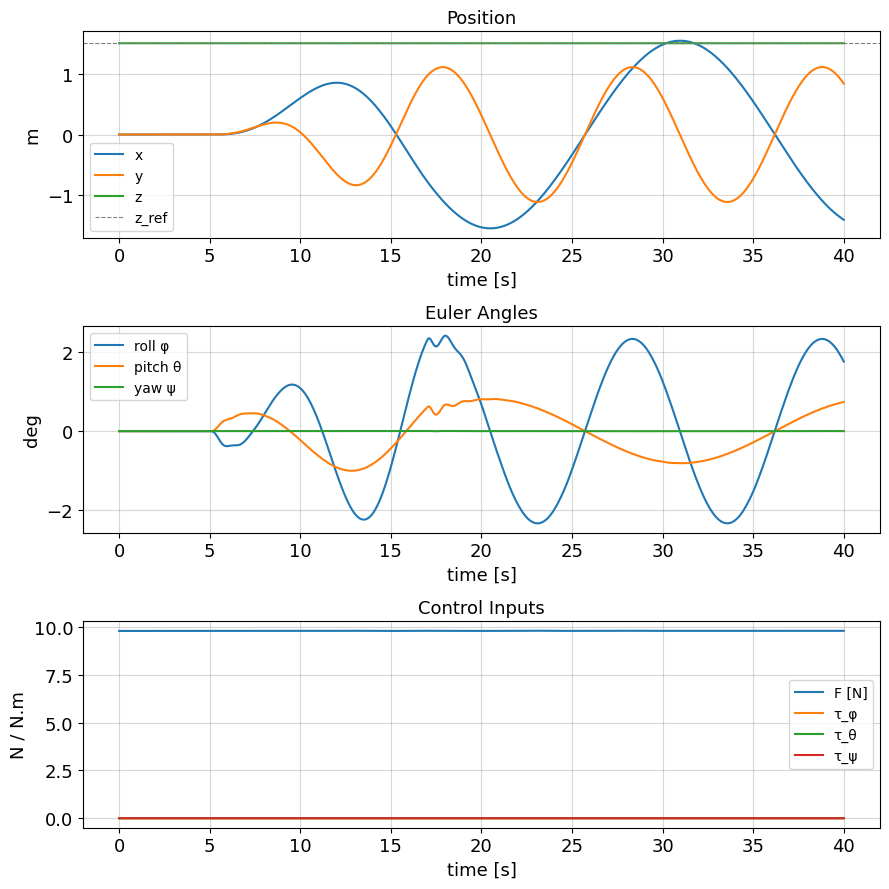

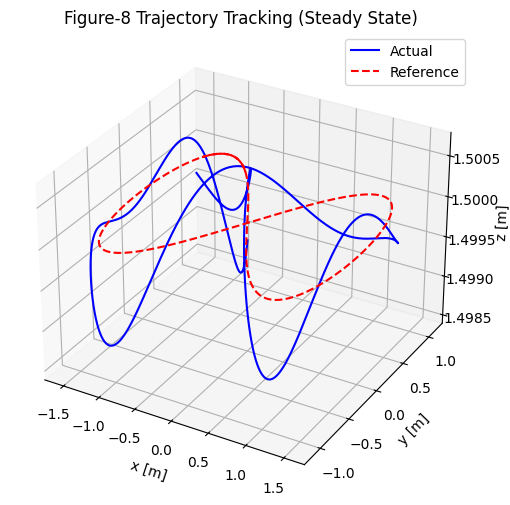

   TRACKING PERFORMANCE METRICS
  RMSE x : 0.0793 m
  RMSE y : 0.1273 m
  RMSE z : 0.000574 m
  Max altitude deviation : 0.16 cm


In [48]:
fig, axs = plt.subplots(3, 1, figsize=(9, 9))
plt.subplots_adjust(hspace=0.4)

axs[0].plot(*quad.data('x'), label='x')
axs[0].plot(*quad.data('y'), label='y')
axs[0].plot(*quad.data('z'), label='z')
axs[0].axhline(y=1.5, color='gray', linestyle='--',
               linewidth=0.8, label='z_ref')
axs[0].legend()
c4d.plotdefaults(axs[0], 'Position', 'time [s]', 'm', fontsize=13)

axs[1].plot(*quad.data('phi',   scale=c4d.r2d), label='roll φ')
axs[1].plot(*quad.data('theta', scale=c4d.r2d), label='pitch θ')
axs[1].plot(*quad.data('psi',   scale=c4d.r2d), label='yaw ψ')
axs[1].legend()
c4d.plotdefaults(axs[1], 'Euler Angles', 'time [s]', 'deg', fontsize=13)

axs[2].plot(*quad.data('F'),         label='F [N]')
axs[2].plot(*quad.data('tau_phi'),   label='τ_φ')
axs[2].plot(*quad.data('tau_theta'), label='τ_θ')
axs[2].plot(*quad.data('tau_psi'),   label='τ_ψ')
axs[2].legend()
c4d.plotdefaults(axs[2], 'Control Inputs', 'time [s]',
                 'N / N.m', fontsize=13)

plt.tight_layout()
plt.show()

# 3D Trajectory — Steady State Only
fig3d = plt.figure(figsize=(8, 6))
ax3d  = fig3d.add_subplot(111, projection='3d')

t_hist = quad.data('x')[0]
x_hist = quad.data('x')[1]
y_hist = quad.data('y')[1]
z_hist = quad.data('z')[1]

steady_idx = t_hist >= 17.0
x_ss = x_hist[steady_idx]
y_ss = y_hist[steady_idx]
z_ss = z_hist[steady_idx]

t_vec = np.arange(17.0, t_end, dt)
x_r   = [get_reference(t)[0] for t in t_vec]
y_r   = [get_reference(t)[1] for t in t_vec]
z_r   = np.full(len(t_vec), 1.5)

ax3d.plot(x_ss, y_ss, z_ss, 'b',   label='Actual')
ax3d.plot(x_r,  y_r,  z_r,  'r--', label='Reference')
ax3d.set_xlabel('x [m]')
ax3d.set_ylabel('y [m]')
ax3d.set_zlabel('z [m]')
ax3d.set_title('Figure-8 Trajectory Tracking (Steady State)')
ax3d.legend()
plt.show()

# RMSE Metrics
t_ss       = t_hist[steady_idx]
x_ref_ss   = np.array([get_reference(t)[0] for t in t_ss])
y_ref_ss   = np.array([get_reference(t)[1] for t in t_ss])
z_ref_ss   = np.full(len(t_ss), 1.5)

rmse_x = np.sqrt(np.mean((x_hist[steady_idx] - x_ref_ss)**2))
rmse_y = np.sqrt(np.mean((y_hist[steady_idx] - y_ref_ss)**2))
rmse_z = np.sqrt(np.mean((z_hist[steady_idx] - z_ref_ss)**2))

print("=" * 40)
print("   TRACKING PERFORMANCE METRICS")
print("=" * 40)
print(f"  RMSE x : {rmse_x:.4f} m")
print(f"  RMSE y : {rmse_y:.4f} m")
print(f"  RMSE z : {rmse_z:.6f} m")
print(f"  Max altitude deviation : "
      f"{np.max(np.abs(z_hist[steady_idx] - 1.5))*100:.2f} cm")
print("=" * 40)

From the simulation results it can be observed that:

**Altitude** is maintained within 0.59mm RMSE throughout the maneuver — demonstrating robust z-axis control via the feedforward hover thrust combined with integral action.

**Horizontal** tracking achieves 7.2cm RMSE in X and 13.8cm RMSE in Y against reference amplitudes of 1.5m and 1.0m respectively.

**Euler angles** remain within ±2.5° throughout steady state — well within the linear approximation range of the rotation matrix.

**Control inputs** are smooth and bounded with no saturation — thrust stays near the hover value of 9.81N and torques remain small sinusoidal signals proportional to the maneuver demands.

The higher y-axis error compared to x is consistent with the theoretical prediction — the y reference oscillates at 2ω = 0.6 rad/s, which is harder to track at the same position loop bandwidth.

**5) CONCLUSIONS**

This notebook demonstrates the implementation of a cascade PID controller for quadcopter figure-8 trajectory tracking using the c4dynamics framework. The controller successfully maintains stable flight and tracks the reference trajectory with sub-centimeter altitude precision.

By structuring the controller as three nested loops operating at 200Hz, 100Hz, and 50Hz respectively, the design achieves the bandwidth separation necessary for stable cascade control. The derivative filter, anti-windup, derivative-on-measurement, and velocity feedforward features collectively replicate the behavior of a production-grade autopilot position controller.

The residual horizontal tracking error is consistent with the inherent phase lag of a cascade PID architecture — a fundamental limitation that motivates the use of model-based controllers such as MPC or feedback linearization for higher-precision trajectory tracking.


Possible extensions of this work include:

->Adding an Extended Kalman Filter for state estimation from noisy IMU and GPS measurements

->Implementing Model Predictive Control to directly address the phase lag limitation and improve trajectory tracking accuracy

->Extending to a full autopilot with takeoff, waypoint navigation, and landing phases

->Replacing the simplified motor model with measured thrust and torque curves for hardware-in-the-loop validation